# Grad-CAM

Gradient-weighted Class Activation Mapping

“For this image and this predicted class, where in the image did the CNN get its evidence?”

In [11]:
import tensorflow as tf

# array of the classes as represented in the model
CLASS_NAMES = [
    "Black Sea Sprat",      # 0
    "Gilt-Head Bream",      # 1
    "Hourse Mackerel",      # 2
    "Red Mullet",           # 3
    "Red Sea Bream",        # 4
    "Sea Bass",             # 5
    "Shrimp",               # 6
    "Striped Red Mullet",   # 7
    "Trout",                # 8
]

# The model that will be evaluated
model = tf.keras.models.load_model("Fish_MN.keras")


"""
If you wish to use a random image you can use random_img_path
If you want to use a misclassified image you can use random_misclassified_img_path
If you want to use a specific image you can use img_path
"""
from gather_image import get_random_image_path, find_misclassified_image
DATASET_FOLDER = "/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset"

random_img_path = get_random_image_path(DATASET_FOLDER, CLASS_NAMES)
print(f"Random image: {random_img_path}")

result = find_misclassified_image(model, CLASS_NAMES, DATASET_FOLDER)
if result:
    random_misclassified_img_path = result["img_path"]
else:
    #Fallback to a misclassified image in case none is found
    random_misclassified_img_path = "/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Gilt-Head Bream/Gilt-Head Bream/00894.png"

# The image that will be valuated. can be changed manually
img_path = "/home/groggy/data/a-large-scale-fish-dataset/2/urelaterte_bilder/1280px-Penaeus_monodon.jpg"


# comment out to use what you choose
#img_path = random_img_path
img_path = random_misclassified_img_path





Random image: /home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Shrimp/Shrimp/00558.png
  ... tried 50 images, still searching...
✓ Found misclassification after 58 attempts!
  True: Striped Red Mullet (class 7)
  Predicted: Red Mullet (class 3)
  Confidence: 50.45%
  Path: /home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Striped Red Mullet/Striped Red Mullet/00011.png


## Compare Grad_CAM with only the predicted class

What we see is:
* Original image
* Heatmap
* * Hot/warm colors (red/yellow) = regions that most influenced the model’s score for the chosen class
* * Cool/dark colors (blue/purple) = regions that contributed less
* Overlay heatmap on image
* * The heatmap is blended onto the original so you can interpret it visually.

Saved to images/Grad-cam_vs_predicted_class.png


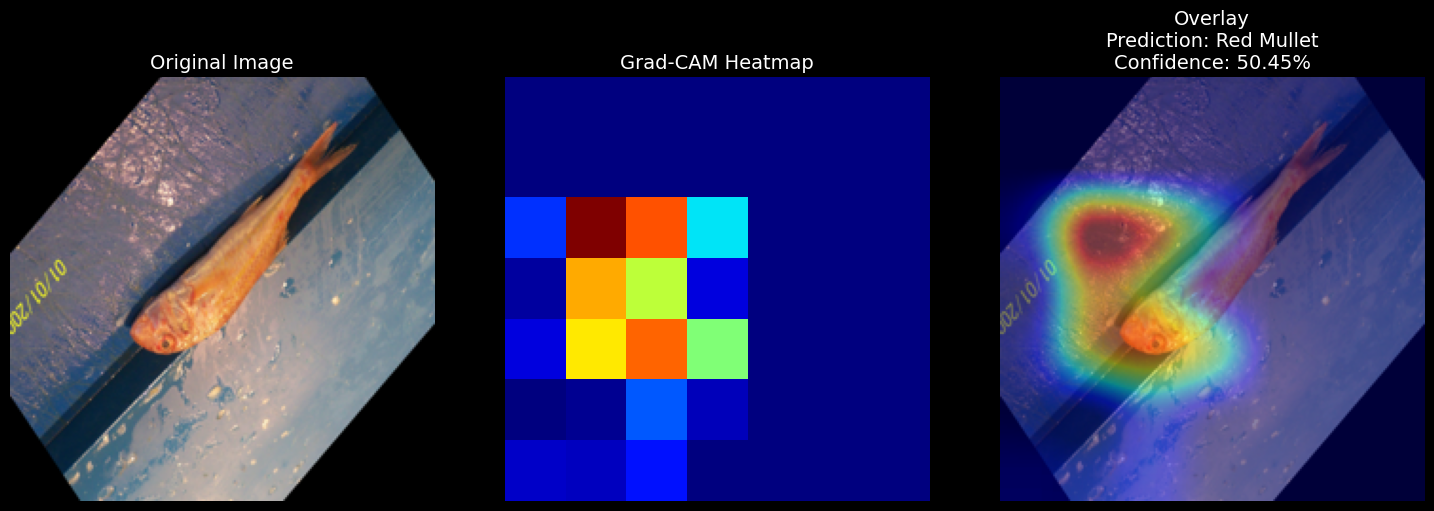

Saved to images/Grad-cam_vs_true_class.png


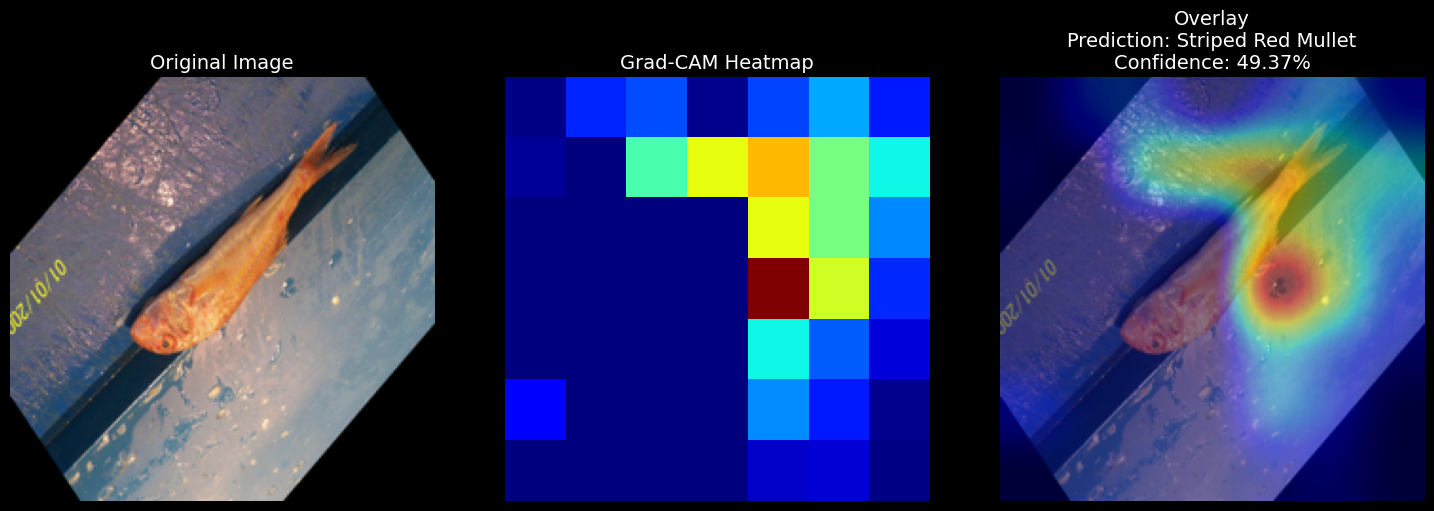

True class: Striped Red Mullet
Predicted class: Striped Red Mullet


In [12]:
from gradcam_single_image import visualize_gradcam

# With class names to show prediction name and confidence
img, heatmap, overlay_img, class_idx = visualize_gradcam(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,  # Add this parameter
    save_path="images/Grad-cam_vs_predicted_class.png"
)

# Force a specific class (e.g., true class)
true_class_idx = CLASS_NAMES.index(img_path.split("/")[-3])
img, heatmap, overlay_img, class_idx = visualize_gradcam(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    class_index=true_class_idx,
    save_path="images/Grad-cam_vs_true_class.png"
)

print(f"True class: {img_path.split('/')[-3]}")
print(f"Predicted class: {CLASS_NAMES[class_idx]}")

## Compare with all 9 classes

Instead of just comparing with the top1 class we compare with all the 9 classes and see what the model lookls at for each class

Model predicts: Red Mullet (class 3) with 50.45% confidence
Saved to images/Grad-cam_vs_all_classes_grid.png


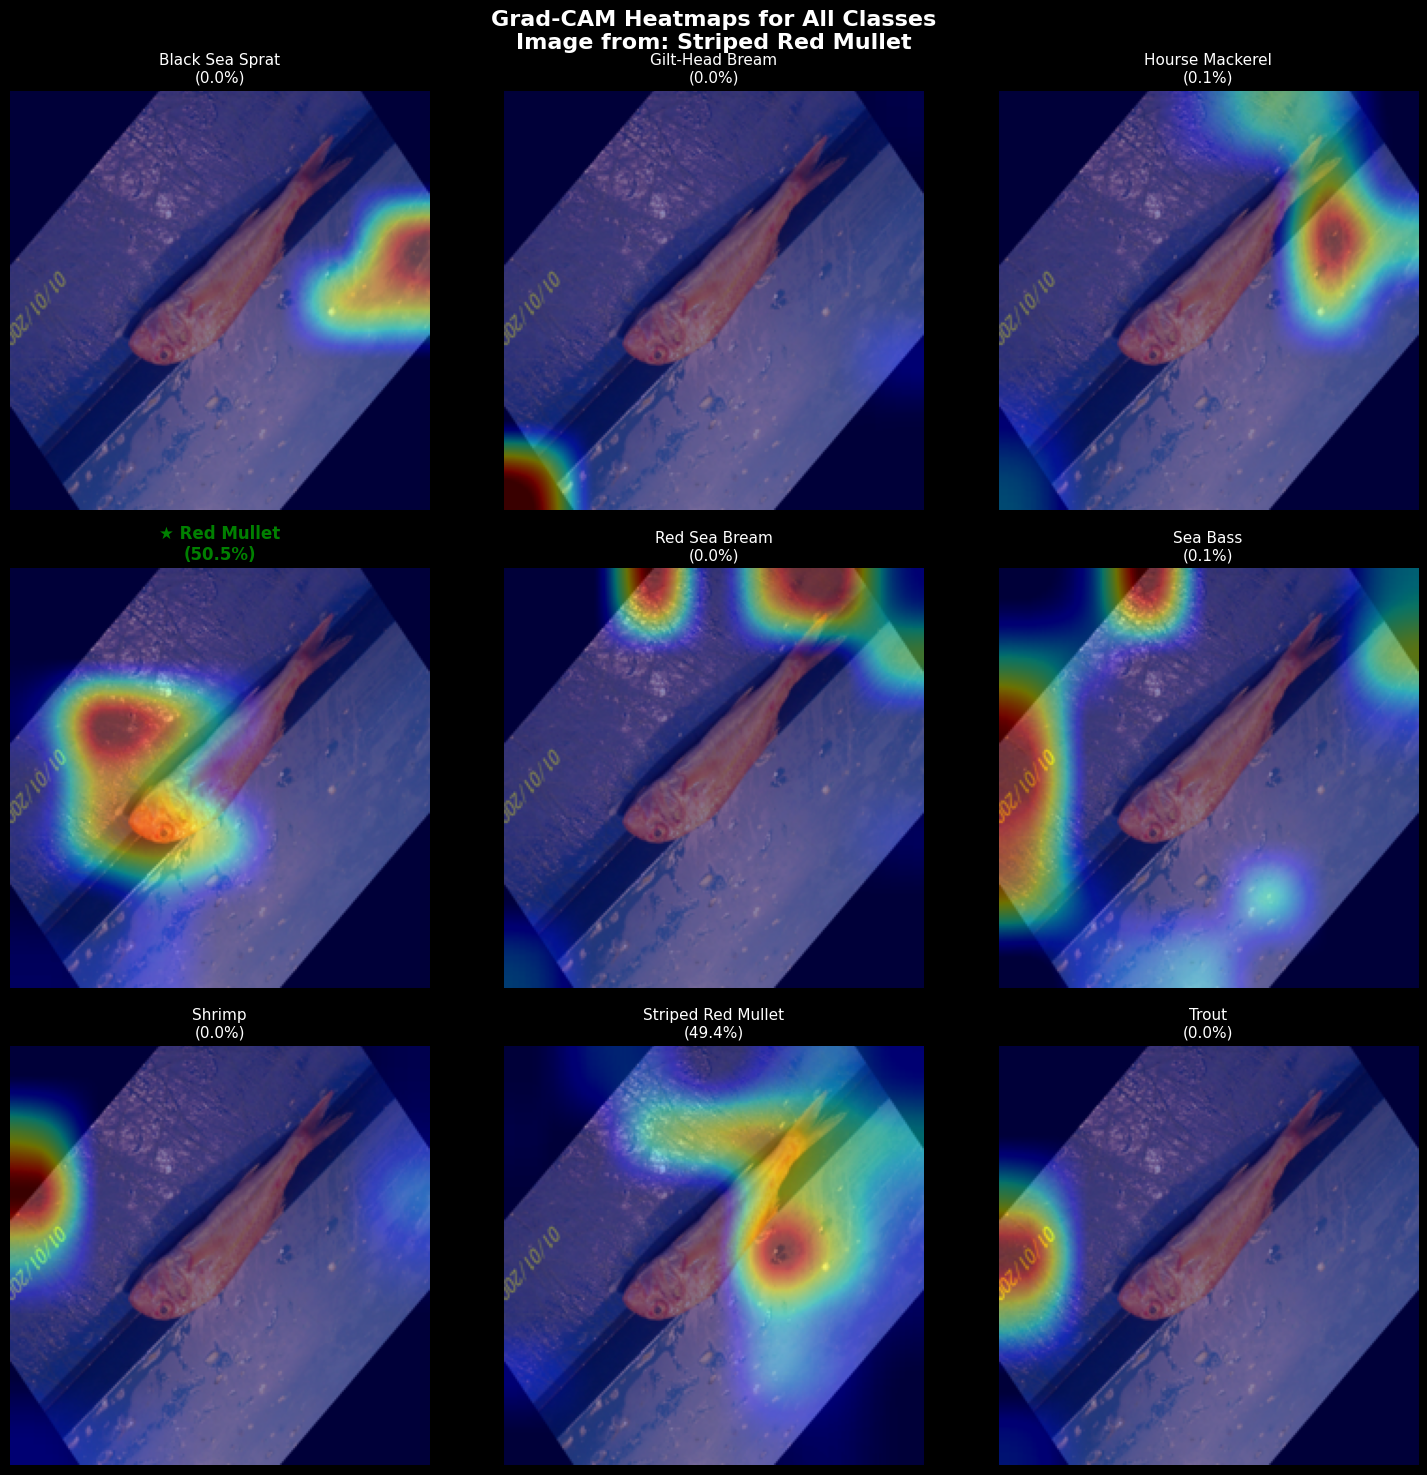


★ = Predicted class: Red Mullet
Predicted: class Red Mullet
True class: Striped Red Mullet
Confidence: 50.45%


In [13]:
from gradcam_all_classes import visualize_gradcam_all_classes

result = visualize_gradcam_all_classes(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    save_path='images/Grad-cam_vs_all_classes_grid.png'
)

# Access the results
print(f"Predicted: class {CLASS_NAMES[result['predicted_class']]}")
print(f"True class: {img_path.split('/')[-3]}")
print(f"Confidence: {result['probabilities'][result['predicted_class']]:.2%}")


# Integrated gradient

Saved to images/ig_vs_predicted_class.png


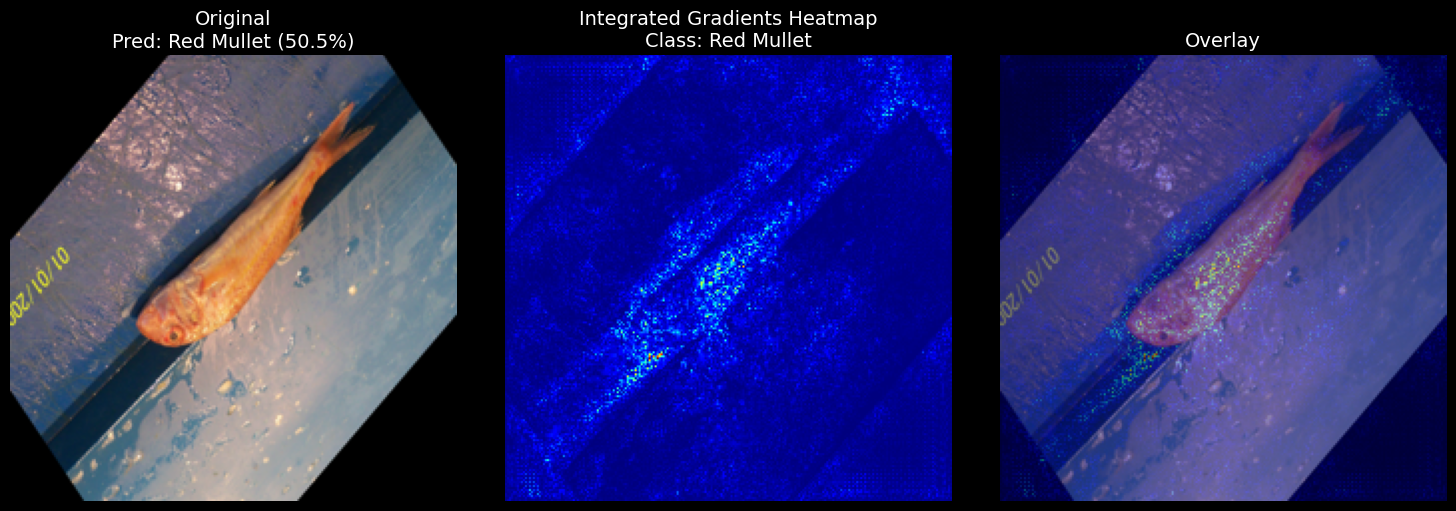

Saved to images/ig_vs_true_class.png


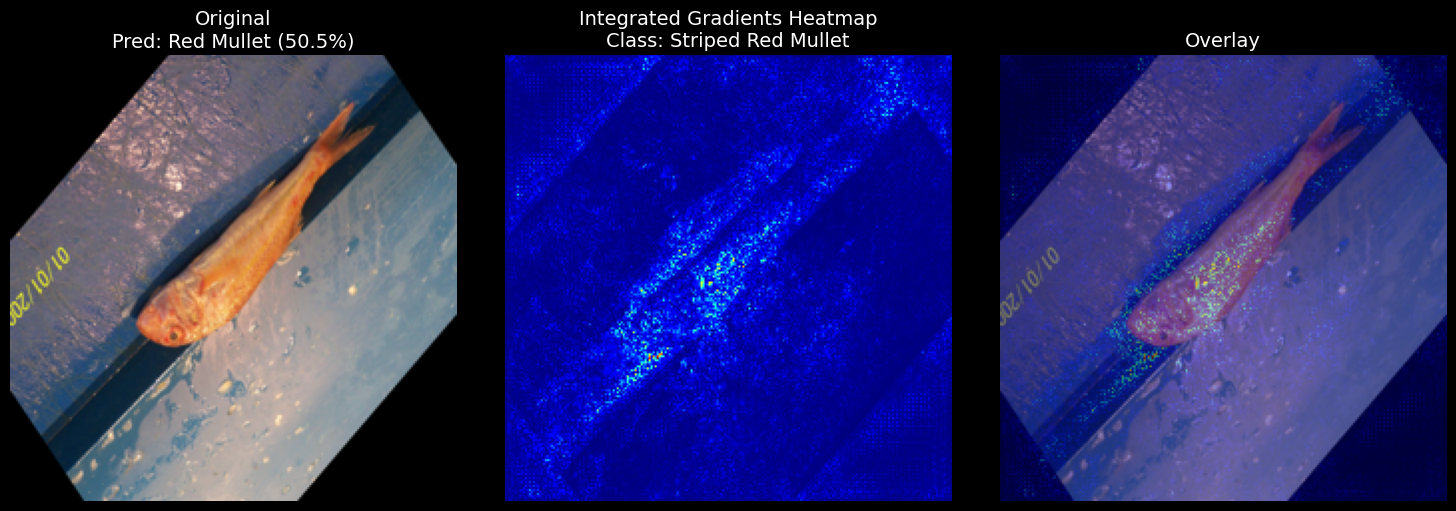

In [15]:
from integrated_gradients_single_image import visualize_integrated_gradients

img, heatmap, overlay_img, class_idx = visualize_integrated_gradients(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    save_path="images/ig_vs_predicted_class.png",
    steps=25
)

# Force a specific class
img, heatmap, overlay_img, class_idx = visualize_integrated_gradients(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    target_class_idx=true_class_idx,
    save_path="images/ig_vs_true_class.png",
    steps=25
)


In [ ]:
from integrated_gradients_all_classes import visualize_integrated_gradients_all_classes

result = visualize_integrated_gradients_all_classes(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    save_path="images/ig_vs_all_classes_grid.png",
    steps=25
)

# Access the results
print(f"Predicted: class {CLASS_NAMES[result['predicted_class']]}")
print(f"Confidence: {result['probabilities'][result['predicted_class']]:.2%}")

Predicted: Red Mullet (class 3) prob=50.45%
